In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

# Fix #1: you're in notebooks/data/, so go up TWO levels to reach kelp_project/data/
data_path = "/Users/tonylin/Documents/kelp_project/1_DATA/raw/LandsatKelpBiomass_2025_Q3_v2_withmetadata.nc"

# Load dataset
ds = xr.open_dataset(data_path, engine="netcdf4")  # force netcdf4 engine
print(ds)


<xarray.Dataset> Size: 4GB
Dimensions:     (station: 594107, time: 167)
Coordinates:
  * time        (time) datetime64[ns] 1kB 1984-02-15 1984-05-15 ... 2025-08-15
Dimensions without coordinates: station
Data variables: (12/13)
    latitude    (station) float64 5MB ...
    longitude   (station) float64 5MB ...
    year        (time) int32 668B ...
    quarter     (time) int16 334B ...
    biomass     (time, station) float64 794MB ...
    biomass_se  (time, station) float64 794MB ...
    ...          ...
    area_se     (time, station) float64 794MB ...
    passes      (time, station) int16 198MB ...
    passes5     (time, station) int16 198MB ...
    passes7     (time, station) int16 198MB ...
    passes8     (time, station) int16 198MB ...
    passes6     (time, station) int16 198MB ...
Attributes: (12/50)
    title:                           SBC LTER: Time series of quarterly NetCD...
    summary:                         Wet biomass (kg) of giant kelp (Macrocys...
    keywords:      

In [2]:
#2 FAST bbox extraction (netCDF4 run-slices)
import numpy as np
import pandas as pd
from netCDF4 import Dataset, num2date
import time

data_path = "/Users/tonylin/Documents/kelp_project/1_DATA/raw/LandsatKelpBiomass_2025_Q3_v2_withmetadata.nc"

# --- your bbox ---
lat_min, lat_max = 38.0, 40.0
lon_min, lon_max = -125.0, -123.0

# --- tuning ---
RUN_MODE_MAX_RUNS = 5000      # if bbox indices form <= this many contiguous runs, use run-mode
BLOCK_SIZE = 100_000          # fallback block scan size (stations)
PRINT_EVERY = 50              # progress prints

t0 = time.time()

with Dataset(data_path, "r") as nc:
    # 1) read coords (fast)
    lat = nc.variables["latitude"][:]
    lon = nc.variables["longitude"][:]
    nstations = lat.shape[0]

    bbox_mask = (lat >= lat_min) & (lat <= lat_max) & (lon >= lon_min) & (lon <= lon_max)
    bbox_idx = np.flatnonzero(bbox_mask).astype(np.int64)

    print("Total stations:", nstations)
    print("Stations in bbox:", bbox_idx.size)

    # 2) build time index (ROBUST: handles cftime objects)
    tvar = nc.variables["time"]
    cal = getattr(tvar, "calendar", "standard")
    time_vals = num2date(tvar[:], units=tvar.units, calendar=cal)

    try:
        time_index = pd.to_datetime(time_vals)
    except Exception:
        time_index = pd.to_datetime([str(t) for t in time_vals])

    ntime = time_index.size

    # 3) prepare area var (turn off auto masking/scaling for speed)
    area = nc.variables["area"]
    try:
        area.set_auto_maskandscale(False)
    except Exception:
        pass

    fill = getattr(area, "_FillValue", None)
    if fill is None:
        fill = getattr(area, "missing_value", None)

    # accumulators
    total = np.zeros(ntime, dtype=np.float64)
    coverage = np.zeros(ntime, dtype=np.int64)

    # 4) compute contiguous runs of bbox station indices
    d = np.diff(bbox_idx)
    breaks = np.where(d != 1)[0]
    run_starts = np.r_[bbox_idx[0], bbox_idx[breaks + 1]]
    run_ends   = np.r_[bbox_idx[breaks] + 1, bbox_idx[-1] + 1]  # end-exclusive

    n_runs = len(run_starts)
    max_run = int(np.max(run_ends - run_starts))
    avg_run = float(bbox_idx.size / n_runs)

    print("Contiguous runs in bbox:", n_runs, "| avg run len:", round(avg_run, 2), "| max run len:", max_run)

    # ------------------------------------------------------------
    # MODE A: Run-mode (slice reads only)
    # ------------------------------------------------------------
    if n_runs <= RUN_MODE_MAX_RUNS:
        print("\nUsing RUN-MODE (slice reads only)")
        bbox_done = 0

        for i, (s, e) in enumerate(zip(run_starts, run_ends), start=1):
            # read contiguous slice (fastest possible access)
            block = np.array(area[:, s:e], dtype=np.float32)  # (time, stations_in_run)

            # valid mask (fast)
            valid = np.isfinite(block)
            if fill is not None:
                valid &= (block != fill)

            # zero invalids then sum
            block[~valid] = 0.0
            total += block.sum(axis=1)
            coverage += valid.sum(axis=1).astype(np.int64)

            bbox_done += (e - s)
            if (i % PRINT_EVERY == 0) or (i == n_runs):
                elapsed = time.time() - t0
                print(f"  runs {i}/{n_runs} | bbox stations processed {bbox_done}/{bbox_idx.size} | elapsed {elapsed:.1f}s")

    # ------------------------------------------------------------
    # MODE B: Block-scan fallback (sequential reads + mask in numpy)
    # ------------------------------------------------------------
    else:
        print("\nUsing BLOCK-SCAN fallback (sequential reads + mask inside numpy)")
        bbox_total = int(bbox_mask.sum())
        bbox_done = 0

        for start in range(0, nstations, BLOCK_SIZE):
            end = min(start + BLOCK_SIZE, nstations)
            m = bbox_mask[start:end]
            if not m.any():
                continue

            # sequential read of a block (fast)
            block = np.array(area[:, start:end], dtype=np.float32)  # (time, block_size)

            valid = np.isfinite(block)
            if fill is not None:
                valid &= (block != fill)

            # apply bbox mask after read
            block = block[:, m]
            valid = valid[:, m]

            block[~valid] = 0.0
            total += block.sum(axis=1)
            coverage += valid.sum(axis=1).astype(np.int64)

            bbox_done += int(m.sum())
            elapsed = time.time() - t0
            print(f"  bbox stations processed {bbox_done}/{bbox_total} | scanned {end}/{nstations} stations | elapsed {elapsed:.1f}s")

# build dataframe
df_kelp = pd.DataFrame(
    {"kelp_area": total, "coverage": coverage},
    index=time_index
).sort_index()

df_kelp["kelp_smooth"] = df_kelp["kelp_area"].rolling(4, center=True, min_periods=1).mean()
df_kelp["coverage_frac"] = df_kelp["coverage"] / df_kelp["coverage"].max()

print("\nDONE")
print("Range:", df_kelp.index.min(), "to", df_kelp.index.max(), "rows:", len(df_kelp))
print(df_kelp.head())

from pathlib import Path

out_dir = Path("../../1_DATA/processed/norcal")
out_dir.mkdir(parents=True, exist_ok=True)

out_csv = out_dir / "kelp_timeseries_norcal_bbox.csv"
df_kelp.to_csv(out_csv, index=True)
print("Saved to:", out_csv.resolve())


Total stations: 594107
Stations in bbox: 29583
Contiguous runs in bbox: 814 | avg run len: 36.34 | max run len: 7574

Using RUN-MODE (slice reads only)
  runs 50/814 | bbox stations processed 144/29583 | elapsed 3.8s
  runs 100/814 | bbox stations processed 2545/29583 | elapsed 7.0s
  runs 150/814 | bbox stations processed 4807/29583 | elapsed 10.3s
  runs 200/814 | bbox stations processed 7035/29583 | elapsed 13.5s
  runs 250/814 | bbox stations processed 7452/29583 | elapsed 16.1s
  runs 300/814 | bbox stations processed 8958/29583 | elapsed 18.9s
  runs 350/814 | bbox stations processed 10986/29583 | elapsed 21.7s
  runs 400/814 | bbox stations processed 14455/29583 | elapsed 24.6s
  runs 450/814 | bbox stations processed 16477/29583 | elapsed 27.3s
  runs 500/814 | bbox stations processed 18234/29583 | elapsed 30.1s
  runs 550/814 | bbox stations processed 19207/29583 | elapsed 33.0s
  runs 600/814 | bbox stations processed 20123/29583 | elapsed 35.8s
  runs 650/814 | bbox stations

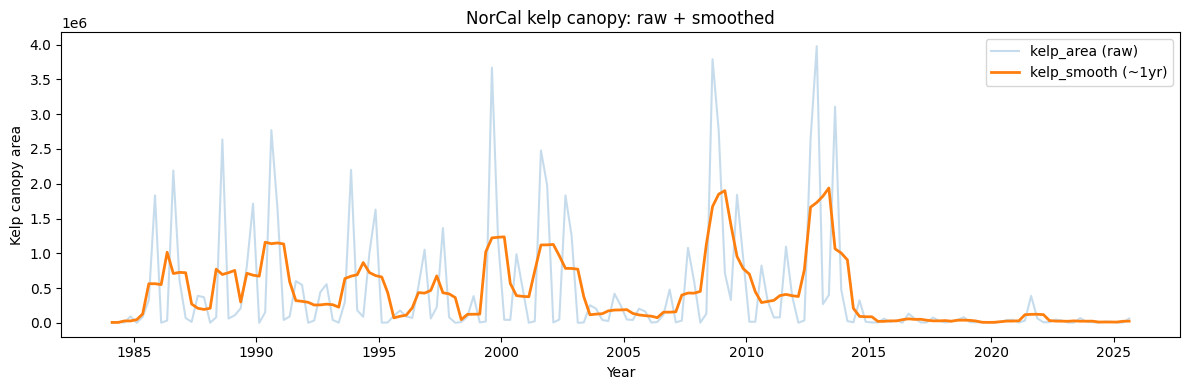

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

fp = "../../1_DATA/processed/norcal/kelp_timeseries_norcalv1_bbox.csv"

df = pd.read_csv(fp)
df[df.columns[0]] = pd.to_datetime(df[df.columns[0]])
df = df.set_index(df.columns[0]).sort_index()

plt.figure(figsize=(12,4))
plt.plot(df.index, df["kelp_area"], alpha=0.25, label="kelp_area (raw)")
plt.plot(df.index, df["kelp_smooth"], linewidth=2, label="kelp_smooth (~1yr)")
plt.title("NorCal kelp canopy: raw + smoothed")
plt.xlabel("Year")
plt.ylabel("Kelp canopy area")
plt.legend()
plt.tight_layout()
plt.show()